# Líneas Base Clásicas para Max-Cut: Fuerza Bruta, Voraz y Goemans–Williamson

**Equipo Isla Verde** — Quantathon 2026, Reto 1 · Open Quantum Institute (OQI)

---

***Resumen—*** *Toda afirmación de rendimiento cuántico exige una línea base
clásica frente al mejor método disponible. Este notebook reporta, para las tres
instancias del proyecto (MVP-8, STD-12, LARGE-16), tres solucionadores clásicos
de Max-Cut: fuerza bruta (óptimo exacto), heurística voraz, y el algoritmo de
redondeo SDP de Goemans–Williamson (garantía $\ge 0.878$). Se computan las
razones de aproximación y se discute con honestidad que, en estas instancias
pequeñas, los métodos clásicos ya alcanzan el óptimo, por lo que superarlos no
constituye evidencia de ventaja cuántica.*

***Términos—*** *Max-Cut, Goemans–Williamson, SDP, razón de aproximación, línea
base clásica.*

## I. INTRODUCCIÓN

La rúbrica del reto pondera la línea base clásica en un 15 % y exige comparar
"frente al método clásico más fuerte disponible". Para Max-Cut, ese método es el
algoritmo de redondeo por programación semidefinida (SDP) de Goemans–Williamson
(GW) [1], con razón de aproximación garantizada $\alpha_{GW}\ge 0.878$. Se
incluyen además una heurística **voraz** ($\approx 0.5$ en el peor caso) y, dado
el tamaño reducido de las instancias, la **fuerza bruta** que entrega el óptimo
exacto y sirve de denominador para la razón de aproximación

$$
r \;=\; \frac{\text{corte del método}}{\text{corte óptimo}} \;\le\; 1.
\tag{1}
$$

## II. MÉTODOS

### A. Fuerza bruta
Enumera los $2^{n}$ estados y devuelve el corte máximo. Exacta pero de coste
exponencial; viable solo para $n\lesssim 20$.

### B. Heurística voraz
Asigna los nodos secuencialmente a la isla que maximiza la ganancia de corte
inmediata. Coste polinómico, sin garantía fuerte.

### C. Goemans–Williamson (SDP)
Relaja cada variable $s_i\in\{-1,+1\}$ a un vector unitario
$\mathbf{v}_i\in\mathbb{R}^{n}$ y resuelve

$$
\max \; \tfrac{1}{2}\sum_{(i,j)\in E} w_{ij}\,(1 - \mathbf{v}_i^\top \mathbf{v}_j)
\quad\text{s.a.}\quad \lVert \mathbf{v}_i\rVert = 1.
\tag{2}
$$

La solución se redondea con un hiperplano aleatorio; el mejor de varios redondeos
garantiza $\mathbb{E}[r]\ge 0.878$. Los cortes se leen de los artefactos ya
calculados por `modelador_red.py` (que usa CVXPY).

## III. RESULTADOS

In [1]:
# --- Setup: permite correr este notebook desde notebooks/ o desde la raiz ---
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "qaoa.py").exists() and (ROOT.parent / "qaoa.py").exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Directorio de trabajo:", ROOT)

Directorio de trabajo: C:\Users\solan\Documents\Personal\Desarrollo_y_Proyectos\Quantathon\Isla-Verde


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

scratch = Path("scratch")
tiers = [t for t in ("mvp8", "std12", "large16")
         if (scratch / f"isla_verde_{t}.json").exists()]
print("Instancias disponibles:", tiers)

data = {t: json.loads((scratch / f"isla_verde_{t}.json").read_bytes().decode("utf-8"))
        for t in tiers}

Instancias disponibles: ['mvp8', 'std12', 'large16']


In [3]:
# Tabla de cortes y razones de aproximación por método e instancia
filas = []
for t in tiers:
    bl = data[t]["baselines"]["maxcut"]
    opt = bl["brute_force"]["cut"]
    gw = bl["goemans_williamson"]
    filas.append({
        "instancia": t,
        "n": len(data[t]["variable_order"]),
        "óptimo": round(opt, 3),
        "fuerza bruta r": 1.0,
        "voraz r": round(bl["greedy"]["cut"] / opt, 4),
        "GW r": round(gw["cut"] / opt, 4) if gw else None,
    })
tabla = pd.DataFrame(filas).set_index("instancia")
tabla

,n,óptimo,fuerza bruta r,voraz r,GW r
instancia,,,,,
mvp8,8,83.731,1.0,1.0000,1.0
std12,12,113.156,1.0,0.9723,1.0
large16,16,291.147,1.0,1.0000,1.0


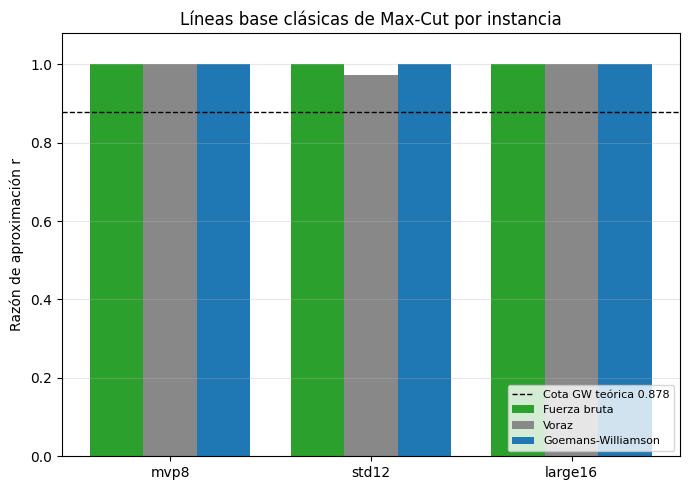

In [4]:
# Fig. 1 — razones de aproximación por instancia y método
metodos = [("fuerza bruta r", "Fuerza bruta", "#2ca02c"),
           ("voraz r", "Voraz", "#888888"),
           ("GW r", "Goemans-Williamson", "#1f77b4")]
x = np.arange(len(tiers)); ancho = 0.8 / len(metodos)
fig, ax = plt.subplots(figsize=(7, 5))
for k, (col, lab, color) in enumerate(metodos):
    vals = [tabla.loc[t, col] if tabla.loc[t, col] is not None else 0 for t in tiers]
    ax.bar(x + k * ancho, vals, width=ancho, label=lab, color=color)
ax.axhline(0.878, color="black", ls="--", lw=1, label="Cota GW teórica 0.878")
ax.set_xticks(x + ancho); ax.set_xticklabels(tiers)
ax.set_ylabel("Razón de aproximación r"); ax.set_ylim(0, 1.08)
ax.set_title("Líneas base clásicas de Max-Cut por instancia")
ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

**Fig. 1.** Razón de aproximación de cada método clásico. En estas
instancias, voraz y GW alcanzan (o casi) el óptimo exacto: la cota teórica
$0.878$ es un **piso** en esperanza para el peor caso, no un techo, y superarla
aquí no implica dificultad ni ventaja alguna.

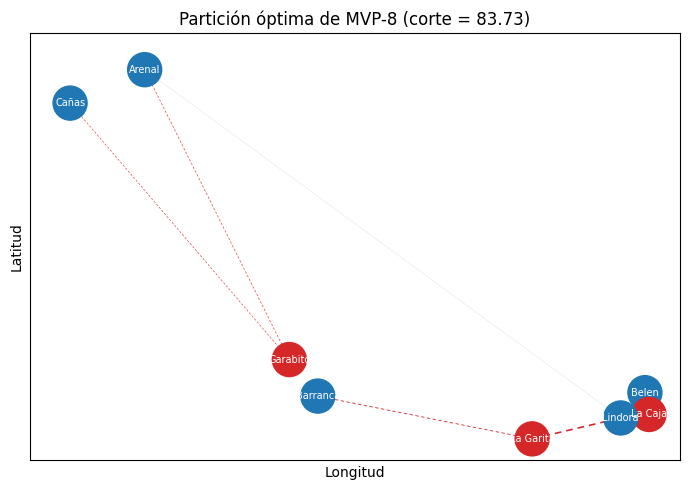

In [5]:
# Fig. 2 — partición óptima (fuerza bruta) sobre el grafo de MVP-8
t = "mvp8"
d = data[t]
order = d["variable_order"]
bitstring = d["baselines"]["maxcut"]["brute_force"]["bitstring"]
isla = {order[i]: int(b) for i, b in enumerate(bitstring)}

G = nx.Graph()
for e in d["edges"]:
    G.add_edge(e["u"], e["v"], weight=e["weight"])
pos = {nd["name"]: (nd["lon"], nd["lat"]) for nd in d["nodes"]}
colores = ["#d62728" if isla[nd] else "#1f77b4" for nd in G.nodes()]

def cortada(u, v): return isla[u] != isla[v]
estilos = ["-" if not cortada(u, v) else (0, (4, 3)) for u, v in G.edges()]
anchos = [G[u][v]["weight"] / 4 for u, v in G.edges()]
col_ar = ["#d62728" if cortada(u, v) else "#cccccc" for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(7, 5))
for (u, v), st, an, cc in zip(G.edges(), estilos, anchos, col_ar):
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)], style=st,
                           width=an, edge_color=cc)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colores, node_size=600)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color="white")
ax.set_title(f"Partición óptima de MVP-8 (corte = "
             f"{d['baselines']['maxcut']['brute_force']['cut']:.2f})")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.tight_layout(); plt.show()

**Fig. 2.** Partición óptima de MVP-8. Los colores distinguen las dos
islas; las líneas rojas discontinuas son las interconexiones cortadas (las que
suman al corte). Esta bipartición es la que un esquema de *islanding* activaría
para aislar la contingencia.

## IV. DISCUSIÓN HONESTA

En las tres instancias, la heurística voraz y GW alcanzan esencialmente el óptimo
exacto. Esto es esperable en grafos pequeños y ponderados como estos, y tiene una
consecuencia importante para la interpretación de los resultados cuánticos:

- La cota $0.878$ **no** es un techo de rendimiento; es una garantía inferior en
  esperanza para el peor caso.
- Como el óptimo clásico ya se alcanza, **superar** a un método clásico aquí es
  imposible (no hay margen) y **no** demostraría ventaja cuántica.
- Los balances de potencia $B_i$ del modelo completo son sintéticos (los CSV del
  ICE no traen MW) y el peso $1/\text{longitud}$ es un *proxy* de acoplamiento,
  no una capacidad eléctrica real.

## V. CONCLUSIÓN

Las tres líneas base quedan establecidas y tabuladas. GW es la referencia clásica
más fuerte y define el listón honesto contra el cual se reporta QAOA en
`03_qaoa.ipynb`.

## REFERENCIAS

[1] M. X. Goemans and D. P. Williamson, "Improved approximation algorithms for
maximum cut and satisfiability problems using semidefinite programming,"
*J. ACM*, vol. 42, no. 6, pp. 1115–1145, 1995.

[2] R. M. Karp, "Reducibility among combinatorial problems," in *Complexity of
Computer Computations*, 1972, pp. 85–103.